# Bài 1 — Biểu diễn dữ liệu thành ma trận & Tính toán phép toán cơ bản & Truy vấn

Họ và tên: Nguyễn Hoàng Nhân  
MSSV: 2412415
Trường: Trường Đại học Bách khoa - ĐHQG TP.HCM  
Sinh viên năm 2  
Ngành: Khoa học máy tính  
Định hướng: Software Engineering và AI Engineering  

Trong bài này, em chọn dữ liệu dạng text.  
Các câu được xây dựng xoay quanh thông tin cá nhân, học tập và định hướng trong lĩnh vực IT.  
Mỗi câu sẽ được biểu diễn thành vector bằng phương pháp Bag-of-Words, sau đó ghép lại thành ma trận X để tính toán các phép toán cũng như truy vấn.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Tạo dữ liệu dạng text 
sentences = [
    "Nguyen Hoang Nhan is a second year student",
    "Nhan studies computer science at HCMUT",
    "Nhan is interested in software engineering and AI engineering",
    "Nhan is an ai beginner learning machine learning",
    "mliot lab teaches python and machine learning",
    "the python and machine learning course helps students build ai foundations",
    "machine learning uses data and models",
    "python helps students learn artificial intelligence",
    "data structures and algorithms support programming",
    "team projects improve communication and problem solving"
]

In [3]:
vocab = []
# Tách mỗi câu thành các danh sách từ và append mỗi từ đó vào mảng vocab
for sentence in sentences:
    words = sentence.lower().split() 
    for word in words:
        if word not in vocab:
            vocab.append(word)
vocab.sort() #sắp xếp lại theo từ điển alphabet

print(vocab)

['a', 'ai', 'algorithms', 'an', 'and', 'artificial', 'at', 'beginner', 'build', 'communication', 'computer', 'course', 'data', 'engineering', 'foundations', 'hcmut', 'helps', 'hoang', 'improve', 'in', 'intelligence', 'interested', 'is', 'lab', 'learn', 'learning', 'machine', 'mliot', 'models', 'nguyen', 'nhan', 'problem', 'programming', 'projects', 'python', 'science', 'second', 'software', 'solving', 'structures', 'student', 'students', 'studies', 'support', 'teaches', 'team', 'the', 'uses', 'year']


Vocabulary là danh sách tất cả các từ khác nhau xuất hiện trong tập câu.  
Mỗi từ trong vocabulary sẽ tương ứng với một cột trong ma trận X.  

In [4]:
# Biến đổi dữ liệu thành Vector
def to_vector(sentence):
    vector = np.zeros(len(vocab)) # Tạo vector 0 với độ dài bằng size of vocab
    words = sentence.lower().split()
    for word in words:
        if word in vocab:
            index = vocab.index(word) # check vị trí của từ đó trong vocab và +1 lên
            vector[index] = vector[index] + 1
    return vector

# Check thử một sentence
print(to_vector("machine learning uses data and models"))

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0.]


In [5]:
# Từ các vector tạo thành Matrix
all_vector = []
for sentence in sentences:
    vector = to_vector(sentence)
    all_vector.append(vector)

# Tạo ma trận X
X = np.array(all_vector)

# In X.shape (shape = kích thước mảng/ ma trận trong numpy)
print("X shape:", X.shape)

X shape: (10, 49)


Ma trận X đã được tạo bằng phương pháp Bag-of-Words.  
Mỗi hàng của X biểu diễn một câu trong tập dữ liệu.  
Mỗi cột của X biểu diễn một từ trong vocabulary.  
Giá trị tại X[i, j] là số lần từ thứ j xuất hiện trong câu thứ i.

In [6]:
# Tính vector trung bình theo cột
mean_vector = X.mean(axis = 0, keepdims = True) # axis=0 tính trung bình theo cột.
print("X shape:", X.shape)
print("MeanVector Shape:", mean_vector.shape)
print("MeanVector:")
print(mean_vector)


X shape: (10, 49)
MeanVector Shape: (1, 49)
MeanVector:
[[0.1 0.3 0.1 0.1 0.6 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.2 0.2 0.1 0.1 0.2 0.1
  0.1 0.1 0.1 0.1 0.3 0.1 0.1 0.5 0.4 0.1 0.1 0.1 0.4 0.1 0.1 0.1 0.3 0.1
  0.1 0.1 0.1 0.1 0.1 0.2 0.1 0.1 0.1 0.1 0.1 0.1 0.1]]


Ma trận X có shape `(10, 49)`, nghĩa là có 10 câu và 49 từ khác nhau trong vocabulary.  
Vector `mean_vector` có shape `(1, 49)` vì nó lưu giá trị trung bình của từng cột trong X.  
Mỗi giá trị trong `mean_vector` cho biết trung bình một từ xuất hiện bao nhiêu lần trong toàn bộ tập câu.

In [7]:
# Tính trừ trung bình (broadcasting)
X_centered = X - mean_vector
print("Before Centering:")
print("X Shape:", X.shape)
print("MeanVector:", mean_vector.shape)

print("After Centering:")
print("X Centered Shape:", X_centered.shape)
print("X centered:", X_centered)

Before Centering:
X Shape: (10, 49)
MeanVector: (1, 49)
After Centering:
X Centered Shape: (10, 49)
X centered: [[ 0.9 -0.3 -0.1 -0.1 -0.6 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.2 -0.2
  -0.1 -0.1 -0.2  0.9 -0.1 -0.1 -0.1 -0.1  0.7 -0.1 -0.1 -0.5 -0.4 -0.1
  -0.1  0.9  0.6 -0.1 -0.1 -0.1 -0.3 -0.1  0.9 -0.1 -0.1 -0.1  0.9 -0.2
  -0.1 -0.1 -0.1 -0.1 -0.1 -0.1  0.9]
 [-0.1 -0.3 -0.1 -0.1 -0.6 -0.1  0.9 -0.1 -0.1 -0.1  0.9 -0.1 -0.2 -0.2
  -0.1  0.9 -0.2 -0.1 -0.1 -0.1 -0.1 -0.1 -0.3 -0.1 -0.1 -0.5 -0.4 -0.1
  -0.1 -0.1  0.6 -0.1 -0.1 -0.1 -0.3  0.9 -0.1 -0.1 -0.1 -0.1 -0.1 -0.2
   0.9 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1]
 [-0.1  0.7 -0.1 -0.1  0.4 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.2  1.8
  -0.1 -0.1 -0.2 -0.1 -0.1  0.9 -0.1  0.9  0.7 -0.1 -0.1 -0.5 -0.4 -0.1
  -0.1 -0.1  0.6 -0.1 -0.1 -0.1 -0.3 -0.1 -0.1  0.9 -0.1 -0.1 -0.1 -0.2
  -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1]
 [-0.1  0.7 -0.1  0.9 -0.6 -0.1 -0.1  0.9 -0.1 -0.1 -0.1 -0.1 -0.2 -0.2
  -0.1 -0.1 -0.2 -0.1 -0.1 -0.1 -0.1 -0.1  0.7 -0.1 -0

Sau khi tính `mean_vector`, em thực hiện trừ trung bình bằng công thức `X_centered = X - mean_vector`.

Ma trận X có shape `(10, 49)`, còn `mean_vector` có shape `(1, 49)`.  
Nhờ broadcasting, NumPy tự động trừ `mean_vector` cho từng hàng của X.

Kết quả `X_centered` vẫn có shape `(10, 49)`, nhưng các giá trị đã thay đổi.  
Giá trị dương nghĩa là từ đó xuất hiện nhiều hơn mức trung bình, còn giá trị âm nghĩa là từ đó xuất hiện ít hơn mức trung bình.

In [8]:
# Cosine similarity
def cosine_similarity(X, Y=None): 
    if Y is None:
        Y = X
    # Tính độ dài X, Y, axis=1 theo hàng
    X_norm = np.linalg.norm(X, axis=1, keepdims=True) 
    Y_norm = np.linalg.norm(Y, axis=1, keepdims=True)

    # Check lỗi chia cho 0 gán cho 1 
    X_norm[X_norm == 0] = 1
    Y_norm[Y_norm == 0] = 1

    # Chuẩn hóa vector về độ lớn
    X_normal = X / X_norm
    Y_normal = Y / Y_norm

    # Tính cosine similarity bằng nhân ma trận X và Y chuyển vị
    similary = X_normal @ Y_normal.T
    return similary

# Kiểm tra với ma trận X
print(cosine_similarity(X).shape)
print(cosine_similarity(X))

(10, 10)
[[1.         0.14433757 0.21320072 0.2236068  0.         0.
  0.         0.         0.         0.        ]
 [0.14433757 1.         0.12309149 0.12909944 0.         0.
  0.         0.         0.         0.        ]
 [0.21320072 0.12309149 1.         0.28603878 0.11396058 0.18181818
  0.12309149 0.         0.12309149 0.11396058]
 [0.2236068  0.12909944 0.28603878 1.         0.35856858 0.38138504
  0.38729833 0.         0.         0.        ]
 [0.         0.         0.11396058 0.35856858 1.         0.45584231
  0.46291005 0.15430335 0.15430335 0.14285714]
 [0.         0.         0.18181818 0.38138504 0.45584231 1.
  0.36927447 0.36927447 0.12309149 0.11396058]
 [0.         0.         0.12309149 0.38729833 0.46291005 0.36927447
  1.         0.         0.33333333 0.15430335]
 [0.         0.         0.         0.         0.15430335 0.36927447
  0.         1.         0.         0.        ]
 [0.         0.         0.12309149 0.         0.15430335 0.12309149
  0.33333333 0.         1. 

Ở bước này, em tính độ tương đồng giữa các câu bằng cosine similarity.

Sau khi biến mỗi câu thành một vector Bag-of-Words, mỗi hàng trong ma trận `X` biểu diễn một câu.  
Nếu hai câu có nhiều từ chung, hai vector của chúng sẽ có hướng gần giống nhau hơn.  
Cosine similarity dùng góc giữa hai vector để đo mức độ giống nhau đó.

Công thức cosine similarity giữa hai vector `x` và `y` là:

`cosine(x, y) = (x · y) / (||x|| ||y||)`

Trong đó:

- `x · y` là tích vô hướng giữa hai vector.
- `||x||` là độ dài của vector `x`.
- `||y||` là độ dài của vector `y`.

Trong code, em dùng:

`np.linalg.norm(X, axis=1, keepdims=True)`

để tính độ dài của từng hàng trong ma trận `X`.  
Vì mỗi hàng là một câu, nên thao tác này tương đương với việc tính độ dài vector của từng câu.

Sau đó, em chuẩn hóa mỗi vector bằng cách chia vector đó cho độ dài của chính nó:

`X_normalized = X / X_norm`

Sau khi chuẩn hóa, mỗi vector có độ dài bằng 1.  
Khi đó, chỉ cần nhân ma trận:

`X_normalized @ Y_normalized.T`

là có thể tính được ma trận cosine similarity cho toàn bộ các cặp câu.

Kết quả `similarity_matrix` có shape `(10, 10)` vì tập dữ liệu có 10 câu.  
Mỗi phần tử tại hàng `i`, cột `j` biểu diễn độ tương đồng giữa câu `i` và câu `j`.

Các phần tử trên đường chéo chính bằng 1 vì mỗi câu giống chính nó hoàn toàn.  
Những giá trị gần 0 cho thấy hai câu ít giống nhau hoặc có rất ít từ chung.  
Những giá trị càng gần 1 cho thấy hai câu càng giống nhau về mặt từ vựng.

In [9]:
# Truy vấn so sánh độ tương đồng 
def search(query, top_k=3):
    # Chuyển câu cần query thành vector
    query_vector = to_vector(query)
    query_matrix =query_vector.reshape(1, -1) # chuyển về ma trận 1 hàng 
    # So sánh cosine similarity với tất cả hàng trong Matrix X 
    scores = cosine_similarity(query_matrix, X)
    scores = scores[0]
    
    result = [] # Lưu [điểm cosine, index câu, nội dung câu]
    for index in range(len(scores)):
        result.append([scores[index], index, sentences[index]])
    result.sort(reverse=True) # sort theo điểm scores từng câu từ lớn đến bé
    top_results = result[:top_k] # lấy ra 3 câu đầu có độ tương đồng nhất
    return top_results

# Check với query = "mliot lab python machine learnin"
print(search("mliot lab python machine learning", top_k=3))

[[np.float64(0.8451542547285166), 4, 'mliot lab teaches python and machine learning'], [np.float64(0.4242640687119285), 3, 'Nhan is an ai beginner learning machine learning'], [np.float64(0.40451991747794525), 5, 'the python and machine learning course helps students build ai foundations']]


Ở bước này, em viết hàm `search(query, top_k=3)` để tìm các câu giống với câu truy vấn nhất.

Đầu tiên, câu truy vấn `query` được chuyển thành vector bằng hàm `to_vector(query)`.  
Vector này có cùng số chiều với các vector trong ma trận `X` vì nó dùng chung vocabulary.

Sau đó, em chuyển `query_vector` từ dạng vector 1 chiều sang ma trận 2 chiều bằng:

`query_vector.reshape(1, -1)`

Việc này giúp query có dạng `(1, số_từ)`, tức là 1 câu và số cột bằng số từ trong vocabulary.  
Hàm `cosine_similarity` xử lý dữ liệu theo từng hàng, nên query cũng cần được đưa về dạng một hàng để so sánh với các hàng trong ma trận `X`.

Tiếp theo, em tính cosine similarity giữa query và toàn bộ các câu trong `X`.  
Kết quả ban đầu có dạng ma trận `(1, số_câu)`, vì có 1 query được so sánh với nhiều câu.  
Sau đó, em lấy `scores[0]` để chuyển kết quả thành danh sách điểm 1 chiều, dễ duyệt bằng vòng lặp.

Mỗi kết quả được lưu dưới dạng:

`[score, index, sentence]`

Trong đó:

- `score` là điểm cosine similarity.
- `index` là vị trí của câu trong tập dữ liệu.
- `sentence` là nội dung câu.

Sau đó, danh sách kết quả được sắp xếp theo điểm cosine từ cao xuống thấp bằng:

`result.sort(reverse=True)`

Cuối cùng, em dùng:

`top_results = result[:top_k]`

để lấy `top_k` câu có điểm cosine cao nhất.  
Ví dụ, nếu `top_k = 3`, hàm sẽ trả về 3 câu giống query nhất.

Với query `"mliot lab python machine learning"`, các câu liên quan đến MLIOT Lab, Python và Machine Learning thường có điểm cao hơn vì có nhiều từ chung với query.

In [10]:
# Check cặp giống nhau nhất và khác biệt nhất từ bộ dữ liệu

similarity_matrix = cosine_similarity(X)

compare_sentences = []

for i in range(similarity_matrix.shape[0]):
    for j in range(i + 1, similarity_matrix.shape[1]):
        score = similarity_matrix[i, j]
        compare_sentences.append([score, i, j])

# Sắp xếp từ điểm cosine cao xuống thấp [score, i, j]
compare_sentences.sort(reverse=True)

# Câu giống nhau nhất nằm ở vị trí đầu tiên
most_similar = compare_sentences[0]

# Câu khác biệt nhất nằm ở vị trí cuối cùng
most_different = compare_sentences[-1]

print("Most Similar:")
print("Sentence", most_similar[1], ":", sentences[most_similar[1]])
print("Sentence", most_similar[2], ":", sentences[most_similar[2]])
print("Cosine score:", float(most_similar[0]))

print("Most Different:")
print("Sentence", most_different[1], ":", sentences[most_different[1]])
print("Sentence", most_different[2], ":", sentences[most_different[2]])
print("Cosine score:", float(most_different[0]))

Most Similar:
Sentence 4 : mliot lab teaches python and machine learning
Sentence 6 : machine learning uses data and models
Cosine score: 0.46291004988627577
Most Different:
Sentence 0 : Nguyen Hoang Nhan is a second year student
Sentence 4 : mliot lab teaches python and machine learning
Cosine score: 0.0


Cặp câu giống nhau nhất là câu 4 và câu 6.

Câu 4 là: `mliot lab teaches python and machine learning`  
Câu 6 là: `machine learning uses data and models`

Hai câu này có điểm cosine similarity là `0.4629`.  
Kết quả này hợp lý vì cả hai câu đều có chung các từ khóa quan trọng như `machine` và `learning`.  
Ngoài ra, nội dung của hai câu đều liên quan đến chủ đề Machine Learning.

Cặp câu khác biệt nhất là câu 0 và câu 4.

Câu 0 là: `Nguyen Hoang Nhan is a second year student`  
Câu 4 là: `mliot lab teaches python and machine learning`

Hai câu này có điểm cosine similarity là `0.0`.  
Điều này hợp lý vì hai câu gần như không có từ chung.  
Câu 0 nói về thông tin cá nhân của em, còn câu 4 nói về MLIOT Lab, Python và Machine Learning.

Nhìn chung, kết quả khớp với trực giác.  
Các câu có nhiều từ chung sẽ có điểm cosine similarity cao hơn, còn các câu không có từ chung sẽ có điểm cosine similarity thấp hơn.

Tuy nhiên, theo em thấy thì phương pháp Bag-of-Words vẫn còn hạn chế vì nó chỉ dựa trên số lần xuất hiện của từ, chưa hiểu được ý nghĩa sâu hoặc ngữ cảnh của câu.

# Bài 2 — Biến đổi tuyến tính & SVD

In [11]:
# Center dữ liệu
Xc = X - X.mean(axis=0, keepdims=True)

# SVD decomposition
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

# Lấy 2 chiều đầu tiên
coords = U[:, :2] * S[:2]

print("X shape:", X.shape)
print("Xc shape:", Xc.shape)
print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)
print("coords shape:", coords.shape)

print()
print("2D coordinates:")
for i in range(len(sentences)):
    print("Sentence", i, ":", coords[i])

X shape: (10, 49)
Xc shape: (10, 49)
U shape: (10, 10)
S shape: (10,)
Vt shape: (10, 49)
coords shape: (10, 2)

2D coordinates:
Sentence 0 : [-1.67136195  0.30139117]
Sentence 1 : [-1.05292734 -0.41954501]
Sentence 2 : [-1.47659719  1.23235006]
Sentence 3 : [0.34986838 1.95922155]
Sentence 4 : [1.12181677 0.03304907]
Sentence 5 : [1.96492487 0.52236068]
Sentence 6 : [ 0.71266539 -0.09063286]
Sentence 7 : [ 0.52321148 -0.86354936]
Sentence 8 : [-0.16530372 -1.20645287]
Sentence 9 : [-0.30629669 -1.46819243]


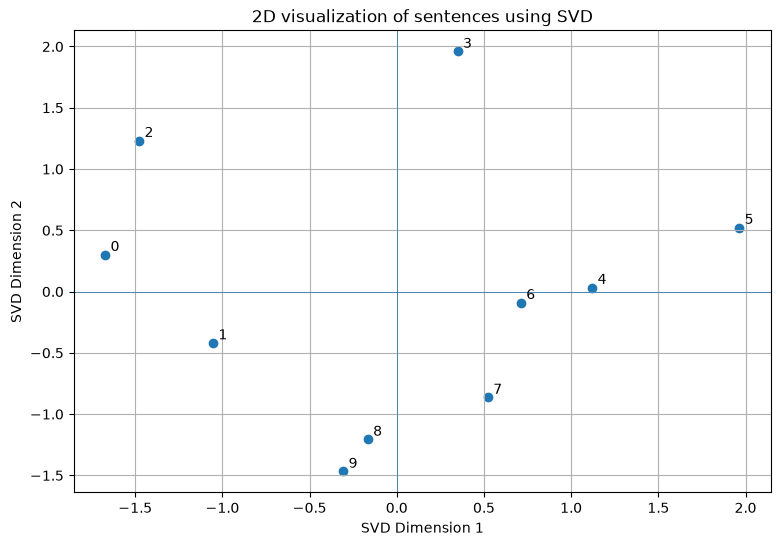

In [12]:
# Trực quan hóa scatter
plt.figure(figsize=(9, 6))

plt.scatter(coords[:, 0], coords[:, 1])

for i in range(len(sentences)):
    plt.text(coords[i, 0] + 0.03, coords[i, 1] + 0.03, str(i))

plt.xlabel("SVD Dimension 1")
plt.ylabel("SVD Dimension 2")
plt.title("2D visualization of sentences using SVD")
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.grid(True)
plt.show()

In [13]:
# In danh sách câu để đối chiếu figure
for i in range(len(sentences)):
    print("Sentence", i, ":", coords[i])

for i in range(len(sentences)):
    print(i, ":", sentences[i])

Sentence 0 : [-1.67136195  0.30139117]
Sentence 1 : [-1.05292734 -0.41954501]
Sentence 2 : [-1.47659719  1.23235006]
Sentence 3 : [0.34986838 1.95922155]
Sentence 4 : [1.12181677 0.03304907]
Sentence 5 : [1.96492487 0.52236068]
Sentence 6 : [ 0.71266539 -0.09063286]
Sentence 7 : [ 0.52321148 -0.86354936]
Sentence 8 : [-0.16530372 -1.20645287]
Sentence 9 : [-0.30629669 -1.46819243]
0 : Nguyen Hoang Nhan is a second year student
1 : Nhan studies computer science at HCMUT
2 : Nhan is interested in software engineering and AI engineering
3 : Nhan is an ai beginner learning machine learning
4 : mliot lab teaches python and machine learning
5 : the python and machine learning course helps students build ai foundations
6 : machine learning uses data and models
7 : python helps students learn artificial intelligence
8 : data structures and algorithms support programming
9 : team projects improve communication and problem solving


Sau khi giảm chiều dữ liệu bằng SVD và vẽ các câu trên mặt phẳng 2D, có thể quan sát rằng các câu có chủ đề gần nhau thường có xu hướng nằm gần nhau hơn.

Ví dụ, các câu liên quan đến `python`, `machine learning`, `AI` hoặc `MLIOT Lab` có xu hướng nằm gần nhau vì chúng chia sẻ nhiều từ khóa chung trong biểu diễn Bag-of-Words.  
Trong kết quả của em, câu 4 và câu 6 là một cặp khá gần nhau vì cả hai đều có các từ chung như `machine` và `learning`.

Ngược lại, các câu có nội dung khác chủ đề, ví dụ câu nói về thông tin cá nhân và câu nói về MLIOT Lab hoặc Machine Learning, có thể nằm xa nhau hơn trên biểu đồ.  
Điều này hợp lý vì các câu này có ít hoặc không có từ chung, nên vector Bag-of-Words của chúng khác nhau hơn.

SVD giúp giảm chiều dữ liệu từ không gian nhiều chiều xuống còn 2 chiều bằng cách tìm ra các hướng quan trọng nhất của dữ liệu.  
Hai chiều được chọn trong `coords = U[:, :2] * S[:2]` có thể xem là hai trục chính đầu tiên của dữ liệu sau khi giảm chiều.

Liên hệ với PCA, PCA cũng tìm các trục chính, tức là các hướng mà dữ liệu thay đổi nhiều nhất.  
Với dữ liệu đã được center, SVD có mối liên hệ chặt chẽ với PCA: các vector trong `Vt` tương ứng với các hướng chính, còn các giá trị trong `S` cho biết mức độ quan trọng của từng hướng.

Nói cách khác, các singular values lớn hơn trong `S` biểu diễn những trục giữ lại nhiều thông tin hơn của dữ liệu.  
Vì vậy, khi lấy hai chiều đầu tiên, ta đang giữ lại hai hướng quan trọng nhất để trực quan hóa dữ liệu trên mặt phẳng 2D.

Tuy nhiên, kết quả trực quan hóa vẫn phụ thuộc vào cách biểu diễn Bag-of-Words.  
Phương pháp này chỉ dựa trên số lần xuất hiện của từ, nên nếu hai câu có ý nghĩa gần nhau nhưng dùng các từ khác nhau, chúng vẫn có thể không nằm gần nhau trên biểu đồ.

# Bài mở rộng — Bộ phân loại 1-NN dựa trên cosine

In [14]:
# Gán label cho từng sentence
for i in range(len(sentences)):
    print(i, ":", sentences[i])

labels = [
    "personal",
    "education",
    "software_ai",
    "ai_machine_learning",
    "ai_machine_learning",
    "ai_machine_learning",
    "ai_machine_learning",
    "ai_machine_learning",
    "programming",
    "teamwork"
]

for i in range(len(labels)):
    print(i, ":", labels[i])

0 : Nguyen Hoang Nhan is a second year student
1 : Nhan studies computer science at HCMUT
2 : Nhan is interested in software engineering and AI engineering
3 : Nhan is an ai beginner learning machine learning
4 : mliot lab teaches python and machine learning
5 : the python and machine learning course helps students build ai foundations
6 : machine learning uses data and models
7 : python helps students learn artificial intelligence
8 : data structures and algorithms support programming
9 : team projects improve communication and problem solving
0 : personal
1 : education
2 : software_ai
3 : ai_machine_learning
4 : ai_machine_learning
5 : ai_machine_learning
6 : ai_machine_learning
7 : ai_machine_learning
8 : programming
9 : teamwork


In [15]:
# Bộ phân loại 1 -NN dựa trên cosine
def predict_1NN(query):
    results = search(query, top_k = 1) # lấy 1 câu có độ tương đồng nhất
    best_result = results[0] # [score, index, sentence]
    score = best_result[0] # lấy score
    index = best_result[1] # lấy index
    nearest_sentence = best_result[2] # lấy sentence
    predicted_label = labels[index]  # lấy nhãn của câu gần nhất
    return predicted_label, nearest_sentence, score

# Check 
query = "ata structures and algorithms at HCMUT so difficult"
predicted_label, nearest_sentence, score = predict_1NN(query)

print("Query:", query)
print("Predicted label:", predicted_label)
print("Nearest sentence:", nearest_sentence)
print("Cosine score:", float(score))


Query: ata structures and algorithms at HCMUT so difficult
Predicted label: programming
Nearest sentence: data structures and algorithms support programming
Cosine score: 0.5477225575051662
